# 03 · Self-supervised pre-training: learn the sensors first, the smell second

Labelling is the expensive part of gas sensing. Every specimen has to be prepared, timed and named. Unlabelled data
costs nothing: a board logging overnight, during burn-in or in an empty room produces hours of it. The idea tested here:

1. **Pre-train** the SensorSetNet encoder on every cycle with **no labels**, using SimCLR's contrastive loss. Two
   augmented versions of the same moment (level drift, noise, a missing sensor) should look alike to the encoder, and
   different from other moments.
2. **Fine-tune** a classifier with only *k* labelled moments per class (k = 5, 10, 25, 50, all).
3. Compare with the same model **trained from scratch** on the same *k* examples.

It uses BME AI-Studio's demo project, which needs AI-Studio installed, or your own data (next cell). It runs on the GPU
if there is one.

> **Whose data is this?** Every result in this notebook comes from **Bosch's demo dataset**, which ships inside BME
> AI-Studio: a 2.5-hour session Bosch recorded next to a La Marzocco espresso machine, on their older **BME688**
> development kit, labelled Air, Espresso Coffee and Filter Coffee. It is *not* data from your board, and not from a
> BME690. It is used here because it is the only labelled gas-sensor data available to everyone, and because it lets
> these tools be checked against AI-Studio's own numbers.
>
> **To run this on your own recordings**, set `recs = lab.load("<your SD card>/bme690")` in the first code cell. Your
> recordings need at least two labelled classes (e.g. coffee and air) to train anything; BME Studio's Quick experiment
> records them that way.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from bme690 import lab
from bme690.lab import models, train, augment, pretrain

# BME AI-Studio keeps its demo project inside its install folder: here /opt/bme-ai-studio (the Linux repack);
# on Windows, resources/app.asar.unpacked/src/config/demo.bmeproject under the AI-Studio folder.
DEMO = Path("/opt/bme-ai-studio/app/src/config/demo.bmeproject")
recs = lab.load_aistudio(DEMO)
# Your own recordings instead:  recs = lab.load("/media/<you>/SDCARD/bme690")
DEVICE = "auto"
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
df = lab.cycles_table(recs)
train.device_of(DEVICE);

training on NVIDIA GeForce RTX 4090 (cuda:0)


## Data

* **Unlabelled pool:** every moment of the session, all 8 sensors (`fused_all(..., labelled_only=False)`), including the
  warm-up, which has no class. Labels are ignored.
* **Task:** Espresso vs Filter Coffee vs Air, with the same split as notebook 02. Whole air specimens are held out, and
  the coffees, one specimen each, are split in time. The test score is therefore optimistic for the coffees. Here it is
  only used to *compare* methods, and all methods share the same test set.
* The *k* labelled examples per class are drawn at random from the training part, three times with different seeds.

Pre-training here uses all cycles, including the test moments' raw signals (never their labels). That is common
practice ("transductive"). While building this notebook, a strict run that left the test moments out of pre-training
did no better.

In [2]:
CLASSES = {"Air": "Air", "Espresso": "Espresso", "Filter Coffee": "Filter Coffee"}
U = lab.fused_all(df, classes=CLASSES, labelled_only=False)       # y = -1 where there is no class
L = U.subset(np.flatnonzero(U.y >= 0))
tr, te = lab.split_by_specimen(L)
pool, test = L.subset(tr), L.subset(te)
print(f"unlabelled pool: {len(U)} moments ({(U.y < 0).sum()} of them warm-up), X {U.X.shape}")
print(f"labelled training pool: {dict(zip(L.labels, np.bincount(pool.y).tolist()))}")
print(f"test: {dict(zip(L.labels, np.bincount(test.y).tolist()))}")
print("⚠ ", lab.split_warning(L))

unlabelled pool: 819 moments (90 of them warm-up), X (819, 8, 11)
labelled training pool: {'Air': 176, 'Espresso': 123, 'Filter Coffee': 136}
test: {'Air': 182, 'Espresso': 53, 'Filter Coffee': 59}
⚠  Espresso, Filter Coffee have only one specimen, so its test data comes from the end of that same specimen and the score is optimistic.


## Pre-training

For the contrastive views, the augmentations are stronger than for supervised training: 12 % level drift per sensor,
2 % noise, and 30 % of sensors dropped. The loss is NT-Xent, where each view has to pick its partner out of 511
others in a 256-moment batch. Chance level is ln(511) ≈ 6.2.

  epoch   60  contrastive loss 3.7198


  epoch  120  contrastive loss 3.5247


  epoch  180  contrastive loss 3.4246


  epoch  240  contrastive loss 3.3790


  epoch  300  contrastive loss 3.3478
18.7 s on cuda:0


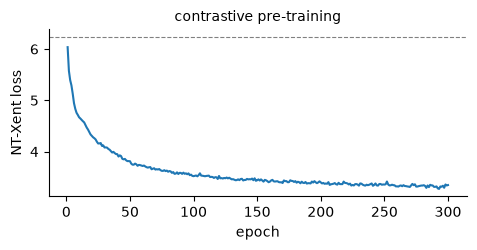

In [3]:
PRE_AUG = augment.Augment("shape", drift=0.05, noise=0.01, dropout=0.3)
train.seed_everything(0)
encoder = models.SensorSetNet.for_samples(L, dim=32)
hist = pretrain.pretrain(encoder, U, augment=PRE_AUG, epochs=300, batch_size=256, temperature=0.2, device=DEVICE)
print(f"{hist['seconds']:.1f} s on {hist['device']}")
plt.figure(figsize=(5, 2.6)); plt.plot(hist["epoch"], hist["loss"]); plt.axhline(np.log(511), ls="--", c="grey", lw=0.8)
plt.xlabel("epoch"); plt.ylabel("NT-Xent loss"); plt.title("contrastive pre-training", fontsize=10); plt.tight_layout()

## Few labels: pre-trained vs from scratch

Four ways to get a classifier from *k* labelled moments per class. Each run gets the same 400 optimiser steps and the
same supervised augmentations.

| method | what trains |
|---|---|
| **scratch** | a fresh SensorSetNet, everything |
| **pre-trained + fine-tune** | the pre-trained SensorSetNet with a new head, everything |
| **pre-trained + linear probe** | only a new head on the frozen pre-trained encoder |
| **random encoder + linear probe** | only a head on a frozen *untrained* encoder (the control for the probe) |

In [4]:
AUG = augment.Augment("shape", drift=0.03, noise=0.005, dropout=0.15)
KS, SEEDS, STEPS = [5, 10, 25, 50, None], [0, 1, 2], 400

def draw(k, seed):
    r = np.random.default_rng(seed)
    idx = [c if k is None else r.choice(c, min(k, len(c)), replace=False)
           for c in (np.flatnonzero(pool.y == y) for y in range(len(L.labels)))]
    return pool.subset(np.concatenate(idx))

train.seed_everything(123)
random_encoder = models.SensorSetNet.for_samples(L, dim=32)
random_encoder.fit_scaler(U.X)

rows, t0 = [], time.time()
for k in KS:
    for seed in SEEDS:
        few = draw(k, seed)
        bs = min(64, len(few))
        kw = dict(epochs=int(np.ceil(STEPS / np.ceil(len(few) / bs))), batch_size=bs, augment=AUG,
                  device=DEVICE, progress=False, seed=seed)
        train.seed_everything(seed)
        m = models.SensorSetNet.for_samples(L, dim=32)
        train.fit(m, few, weight_decay=1e-4, **kw)
        runs = {"scratch": m,
                "pre-trained + fine-tune": pretrain.fine_tune(encoder, few, mode="full", lr=1e-3, **kw)[0],
                "pre-trained + linear probe": pretrain.fine_tune(encoder, few, mode="linear", lr=3e-3, **kw)[0],
                "random encoder + linear probe": pretrain.fine_tune(random_encoder, few, mode="linear", lr=3e-3, **kw)[0]}
        for method, model in runs.items():
            r = train.evaluate(model, test)
            rows.append({"k": "all" if k is None else k, "n labelled": len(few), "seed": seed, "method": method,
                         "accuracy": r["accuracy"], "balanced accuracy": r["balanced_accuracy"]})
print(f"{len(rows)} runs in {time.time() - t0:.0f} s")
res = pd.DataFrame(rows)
mean_sd = lambda v: f"{np.mean(v):.3f} ± {np.std(v):.3f}"
res.pivot_table(index="k", columns="method", values="accuracy", aggfunc=mean_sd, sort=False)

60 runs in 161 s


method,scratch,pre-trained + fine-tune,pre-trained + linear probe,random encoder + linear probe
k,,,,
5,0.829 ± 0.029,0.806 ± 0.015,0.500 ± 0.006,0.782 ± 0.000
10,0.850 ± 0.075,0.857 ± 0.077,0.464 ± 0.013,0.781 ± 0.002
25,0.913 ± 0.035,0.876 ± 0.038,0.495 ± 0.013,0.786 ± 0.005
50,0.955 ± 0.021,0.973 ± 0.006,0.508 ± 0.003,0.787 ± 0.006
all,0.963 ± 0.003,0.976 ± 0.007,0.505 ± 0.004,0.785 ± 0.002


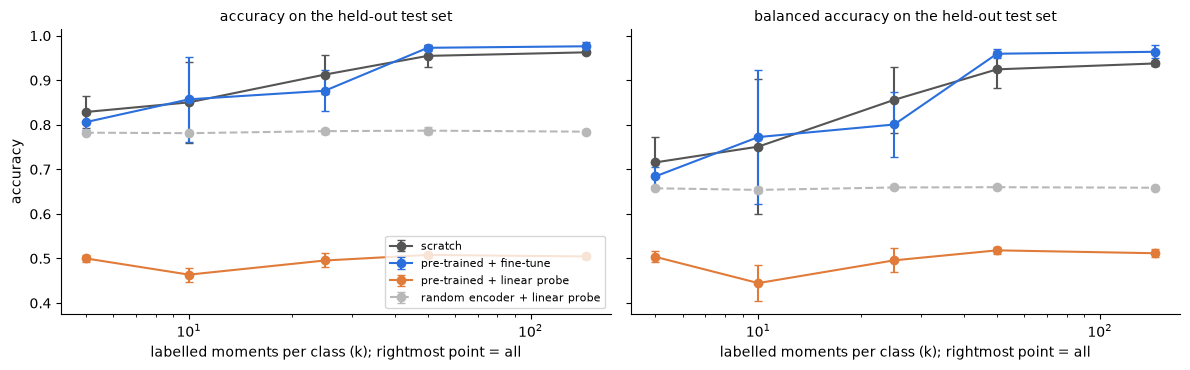

In [5]:
colors = {"scratch": "#555555", "pre-trained + fine-tune": "#2a6fdb", "pre-trained + linear probe": "#e07b39",
          "random encoder + linear probe": "#b8b8b8"}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, metric in zip(axes, ["accuracy", "balanced accuracy"]):
    for method, g in res.groupby("method", sort=False):
        s = g.groupby("n labelled", sort=True)[metric].agg(["mean", "std"])
        ax.errorbar(s.index / len(L.labels), s["mean"], yerr=s["std"], marker="o", capsize=3, label=method,
                    color=colors[method], ls="--" if "random" in method else "-")
    ax.set_xscale("log"); ax.set_xlabel("labelled moments per class (k); rightmost point = all")
    ax.set_title(metric + " on the held-out test set", fontsize=10)
axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()

## Why the linear probe fails here: what the encoder learned

A contrastive encoder learns whatever makes one moment different from another. In a single 2.4-hour session, the
biggest difference between moments is often **when** they were recorded, as the sensors settle and drift, and not
what was in the air. The PCA below shows the pre-trained embedding coloured by specimen. When the specimens form
separate islands, even for the same class (the three air specimens), a linear head trained on one air specimen
cannot recognise another. Full fine-tuning repairs this because it retrains the encoder.

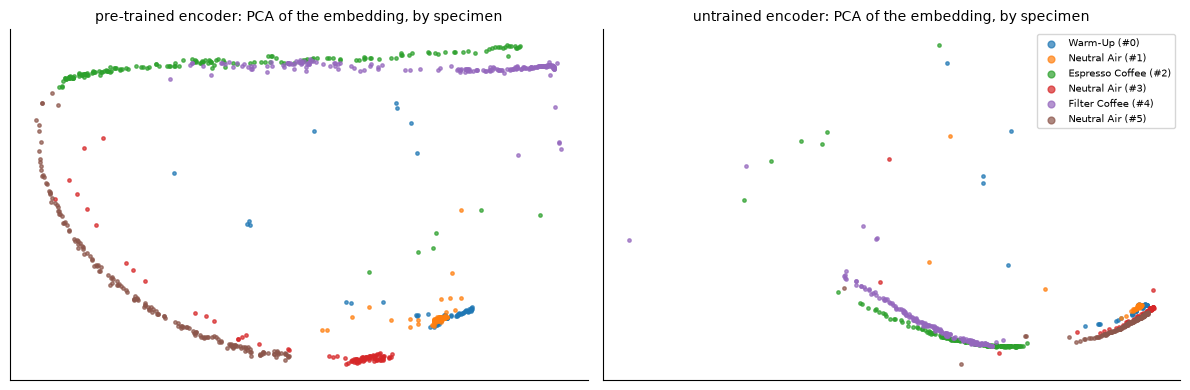

In [6]:
def embed(net, X):
    net.eval()
    with torch.no_grad():
        return net.to(next(net.parameters()).device).encode(torch.tensor(X, device=next(net.parameters()).device)).cpu().numpy()

names = recs[0].specimens["name"].tolist()
spec = np.array([int(g.split(":")[1]) for g in U.groups])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, net) in zip(axes, [("pre-trained encoder", encoder), ("untrained encoder", random_encoder)]):
    z = embed(net, U.X)
    z = z - z.mean(0)
    pc = z @ np.linalg.svd(z, full_matrices=False)[2][:2].T
    for sp in np.unique(spec):
        mk = spec == sp
        ax.scatter(pc[mk, 0], pc[mk, 1], s=6, label=f"{names[sp]} (#{sp})", alpha=0.7)
    ax.set_title(f"{title}: PCA of the embedding, by specimen", fontsize=10); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(fontsize=7, markerscale=2, loc="best")
plt.tight_layout()

## Verdict on this dataset

Read the numbers above. On the demo project:

* **Pre-training then fine-tuning** does not deliver the few-label win. At k = 5 and 25 it is behind training from
  scratch, and at k = 10 the error bars overlap. It pulls ahead only once labels are plentiful: about +1.5 points at
  k = 50 and with all labels, over three draws of one pre-trained encoder. That looks more like a better
  initialisation than learned chemistry.
* **The frozen pre-trained encoder is worse than a random one.** Contrastive learning on one session mostly learned to
  tell specimens and times apart, which is the drift of this one session and not the chemistry.
* Both results come from the data, not the method. The unlabelled pool is 145 minutes of the same session the labels
  come from, and 90 of its 819 moments are unlabelled. Self-supervision pays off when the unlabelled data is much
  larger and more varied than the labelled data.

**What would make it matter:**

* **Hours of unlabelled logging across days**: the board's burn-in, overnight room air, a week on the kitchen counter.
  Days of drift, humidity and temperature changes teach the encoder what does *not* matter.
* **Several sessions and boards**, so "which session is this" stops being the easiest thing to learn. With the lab's
  data layer this is just more `.bmerawdata` files in `lab.load(...)`.
* **Augmentations matched to the real nuisances.** Once there are hours of data, fit the drift and noise sizes to what
  the burn-in shows.
* Then test with `leave_one_recording_out`: pre-training should help most on a new day, when the labelled data is small
  and the sensors have drifted.

The pipeline is in place. When the burn-in logs are available, run this notebook with `U` built from them.